In [7]:
import os
import sys
os.chdir(r'c:\Users\willi\ETE26\log635\LOG635-eqG-lab2') 
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support
import time
import warnings
warnings.filterwarnings('ignore')

from features import load_dataset, image_db_to_arrays

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

ImportError: cannot import name 'image_db_to_arrays' from 'features' (c:\Users\willi\ETE26\log635\LOG635-eqG-lab2\features.py)

In [6]:
%load_ext autoreload
%autoreload 2

Chargement de Ensemble_B...
DEBUG load_dataset: 3 echantillon(s) aleatoire(s)
--------------------------------------------------------------------------------
Index: 1995
Classe: Diamant2 (label=2)
Fichier: Ensemble_B\Diamant2\486Diamant2.png
Pixels[0:10]: [0.2454 0.3696 0.4411 0.4576 0.4543 0.4577 0.4697 0.4743 0.4787 0.48  ]
Extra features: [3.     0.2651]


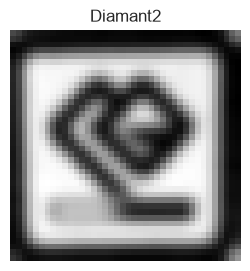

--------------------------------------------------------------------------------
Index: 3035
Classe: Hexagone2 (label=4)
Fichier: Ensemble_B\Hexagone2\592Hexagone2.png
Pixels[0:10]: [0.3653 0.2781 0.1642 0.1091 0.0956 0.0977 0.1008 0.0975 0.0936 0.0968]
Extra features: [5.     0.1524]


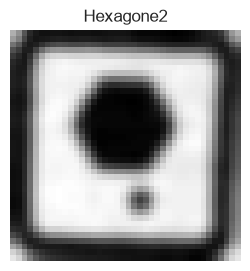

--------------------------------------------------------------------------------
Index: 3618
Classe: Hexagone5 (label=5)
Fichier: Ensemble_B\Hexagone5\286Hexagone5.png
Pixels[0:10]: [0.0549 0.0648 0.1182 0.2373 0.3625 0.4288 0.4467 0.4506 0.4501 0.4382]
Extra features: [2.     0.2238]


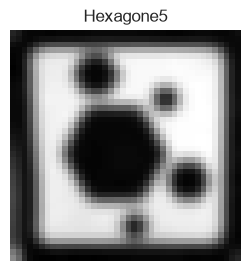

5685 images, 1026 features, 8 classes
   Classes: ['Cercle2', 'Cercle5', 'Diamant2', 'Diamant5', 'Hexagone2', 'Hexagone5', 'Triangle2', 'Triangle5']


In [ ]:
DATA_DIR = 'Ensemble_B'
IMAGE_SHAPE = (32, 32)
RANDOM_STATE = 0

print(f'Chargement de {DATA_DIR}...')
Xpix, Xextra, y_flat, class_names, image_db = load_dataset(
    DATA_DIR,
    image_shape=IMAGE_SHAPE,
    debug_samples=3,
    debug_seed=0,
    show_debug_images=True,
    return_image_db=True,
)

if Xpix is None:
    raise RuntimeError('Aucune image chargee')

X, y = image_db_to_arrays(image_db)
if X is None:
    raise RuntimeError('image_db vide apres conversion')

D = X.shape[1]  # Nombre de features
C = len(class_names)  # Nombre de classes

print(f'image_db contient {len(image_db)} classes')
print(f'{X.shape[0]} images, {D} features, {C} classes')
print(f'   Classes: {class_names}')

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.80, stratify=y, random_state=RANDOM_STATE
)

# Standardisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {X_train_scaled.shape[0]}, Test: {X_test_scaled.shape[0]}')

In [ ]:
results = {}

models_sklearn = {
    'SVM': SVC(kernel='rbf', C=1.0, random_state=RANDOM_STATE),
    'kNN': KNeighborsClassifier(n_neighbors=5),
    'RN_sklearn': MLPClassifier(hidden_layer_sizes=(128,), max_iter=300, random_state=RANDOM_STATE)
}

print('Entraînement des modeles sklearn...')
for name, model in models_sklearn.items():
    print(f'  {name}...', end=' ', flush=True)
    
    t0 = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - t0
    
    t1 = time.time()
    y_pred = model.predict(X_test_scaled)
    predict_time = time.time() - t1
    
    acc = accuracy_score(y_test, y_pred)
    p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    
    results[name] = {
        'y_pred': y_pred,
        'accuracy': acc,
        'precision': p,
        'recall': r,
        'f1': f,
        'train_time': train_time,
        'predict_time': predict_time,
        'cm': cm
    }
    
    print(f'Acc={acc:.2%}')

print('\nModeles sklearn entraînes!')

In [ ]:
#TODO entraintement du reseau de neurones maison


# Pour validation et test
acc_nn = accuracy_score(y_test, y_pred_nn)
p_nn, r_nn, f_nn, _ = precision_recall_fscore_support(y_test, y_pred_nn, average='macro', zero_division=0)
cm_nn = confusion_matrix(y_test, y_pred_nn)

results['Réseau_Maison'] = {
    'y_pred': y_pred_nn,
    'accuracy': acc_nn,
    'precision': p_nn,
    'recall': r_nn,
    'f1': f_nn,
    'train_time': train_time,
    'predict_time': predict_time,
    'cm': cm_nn
}

print()
print(f'Test: Acc={acc_nn:.2%}, Train time={train_time:.3f}s')

In [ ]:
print('\n' + '='*90)
print('COMPARAISON DES 4 MODELES')
print('='*90)

summary_data = []
for name, res in results.items():
    summary_data.append({
        'Modèle': name,
        'Accuracy': f'{res["accuracy"]:.1%}',
        'Précision': f'{res["precision"]:.3f}',
        'Rappel': f'{res["recall"]:.3f}',
        'F1': f'{res["f1"]:.3f}',
        'Entraînement (s)': f'{res["train_time"]:.4f}',
        'Prédiction (ms)': f'{res["predict_time"]*1000:.2f}'
    })

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))
print('='*90)

## 7. Matrices de Confusion

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (model_name, res) in enumerate(sorted(results.items())):
    ax = axes[idx]
    cm = res['cm']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
               xticklabels=class_names, yticklabels=class_names)
    ax.set_title(f'{model_name}\nAcc={res["accuracy"]:.1%}', 
                fontsize=12, fontweight='bold')
    ax.set_ylabel('Vraie classe')
    ax.set_xlabel('Prédiction')

plt.tight_layout()
plt.savefig('comparison_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print('Matrices de confusion sauvegardees')

## 8. Graphes Comparatifs

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Accuracy
models_list = list(results.keys())
accuracies = [results[m]['accuracy']*100 for m in models_list]
train_times = [results[m]['train_time'] for m in models_list]
pred_times = [results[m]['predict_time']*1000 for m in models_list]

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

# Accuracy
ax = axes[0]
bars = ax.bar(models_list, accuracies, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}%',
           ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontweight='bold')
ax.set_title('Accuracy', fontsize=12, fontweight='bold')
ax.set_ylim([0, 110])
ax.tick_params(axis='x', rotation=45)

# Temps d'entraînement
ax = axes[1]
bars = ax.bar(models_list, train_times, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.3f}s',
           ha='center', va='bottom', fontweight='bold', fontsize=9)
ax.set_ylabel('Temps (secondes)', fontweight='bold')
ax.set_title('Temps d\'entraînement', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45)

# Temps de prédiction
ax = axes[2]
bars = ax.bar(models_list, pred_times, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}ms',
           ha='center', va='bottom', fontweight='bold', fontsize=9)
ax.set_ylabel('Temps (ms)', fontweight='bold')
ax.set_title('Temps de prédiction', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('comparison_graphs.png', dpi=150, bbox_inches='tight')
plt.show()

print('Graphes comparatifs sauvegardés')